<a href="https://colab.research.google.com/github/silviaparente/computational_astrobiology/blob/main/naive_bayes_exoplanet_archive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Naive Bayes on NASA Exoplanet Archive data

This Colab notebook shows a full **master-level workflow** for downloading confirmed exoplanet data from the **NASA Exoplanet Archive**, preparing features, defining a supervised target, training a **Gaussian Naive Bayes** classifier, and evaluating the results.

## What this notebook does

We use the **Planetary Systems Composite Parameters** table (`pscomppars`), which provides one row per confirmed planet and is intended for statistical studies. The Archive documents that `pscomppars` is a more filled-in table with one row per planet, but it may combine values from multiple references, so it is convenient for demographics but not always fully self-consistent. The Archive also recommends using the TAP service for current programmatic access.

In this demo, the default target is:

`is_transit = 1 if discoverymethod == 'Transit' else 0`

That target is useful for learning the method, but it is **not** a deep physical class: it reflects observational selection effects as well as planet properties. After you get the workflow running, you can replace the target with a more science-driven label.

## Data source

This notebook queries the NASA Exoplanet Archive TAP service, which supports access to `ps` and `pscomppars`, and the `pscomppars` table is documented as the statistical one-row-per-planet table. See the official Archive documentation for details.

Official references:
- TAP guide: https://exoplanetarchive.ipac.caltech.edu/docs/TAP/usingTAP.html
- PS/PSCompPars table definitions: https://exoplanetarchive.ipac.caltech.edu/docs/API_PS_columns.html
- About `pscomppars`: https://exoplanetarchive.ipac.caltech.edu/docs/pscp_about.html

## Suggested student extensions

After running the baseline notebook, try:
1. replacing the target with a physical label,
2. comparing Gaussian Naive Bayes with Logistic Regression,
3. using balanced metrics for imbalanced classes,
4. checking feature correlations and discussing why Naive Bayes can still work despite violated independence assumptions.


## 1. Install and import packages

In Google Colab, the core packages are usually already available, but this cell is harmless and ensures a consistent environment.

In [ ]:
!pip -q install pandas numpy scikit-learn matplotlib requests

In [ ]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
)


## 2. Download data from the NASA Exoplanet Archive

We query the **TAP** endpoint with a SQL-like ADQL statement. The `pscomppars` table gives one row per confirmed planet and is commonly used for demographic analyses.

We intentionally request a compact subset of columns that are convenient for a first supervised-learning exercise.

In [ ]:
# TAP sync endpoint
base_url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"

# A compact query for confirmed planets from pscomppars
query = r"""
select
    pl_name,
    hostname,
    discoverymethod,
    pl_orbper,
    pl_orbsmax,
    pl_rade,
    pl_bmasse,
    pl_dens,
    pl_orbeccen,
    pl_eqt,
    pl_insol,
    st_teff,
    st_rad,
    st_mass,
    st_met,
    st_logg,
    sy_dist,
    sy_snum,
    sy_pnum
from pscomppars
"""

import urllib.parse

url = f"{base_url}?query={urllib.parse.quote(query)}&format=csv"
df = pd.read_csv(url)

print(df.shape)
df.head()

(6147, 19)


,pl_name,hostname,discoverymethod,pl_orbper,pl_orbsmax,pl_rade,pl_bmasse,pl_dens,pl_orbeccen,pl_eqt,pl_insol,st_teff,st_rad,st_mass,st_met,st_logg,sy_dist,sy_snum,sy_pnum
0,Kepler-1167 b,Kepler-1167,Transit,1.003934,0.01750,1.710000,3.570,3.92,0.0,1419.0,1039.697,4971.0,0.750,0.790,-0.05,4.600,820.905,1,1
1,Kepler-1740 b,Kepler-1740,Transit,8.172400,0.07790,3.323214,11.000,1.65,0.0,858.0,127.950,5705.0,0.905,0.943,-0.06,4.499,1061.770,1,1
2,Kepler-1581 b,Kepler-1581,Transit,6.283855,0.06865,0.800000,0.437,4.69,0.0,1108.0,470.862,6022.0,1.230,1.120,0.07,4.310,493.175,1,1
3,Kepler-644 b,Kepler-644,Transit,3.173917,0.04641,3.150000,10.100,1.78,0.0,1655.0,2381.770,6747.0,1.810,1.490,0.08,4.090,1318.050,1,1
4,Kepler-1752 b,Kepler-1752,Transit,56.358501,0.26980,4.540605,18.700,1.10,0.0,419.0,7.290,5446.0,0.821,0.824,-0.20,4.525,962.888,1,1


## 3. Quick inspection

It is always worth checking how much missing data you have and how the classes are distributed.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6147 entries, 0 to 6146
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          6147 non-null   object 
 1   hostname         6147 non-null   object 
 2   discoverymethod  6147 non-null   object 
 3   pl_orbper        5814 non-null   float64
 4   pl_orbsmax       5831 non-null   float64
 5   pl_rade          6097 non-null   float64
 6   pl_bmasse        6116 non-null   float64
 7   pl_dens          6009 non-null   float64
 8   pl_orbeccen      5211 non-null   float64
 9   pl_eqt           4585 non-null   float64
 10  pl_insol         4308 non-null   float64
 11  st_teff          5858 non-null   float64
 12  st_rad           5834 non-null   float64
 13  st_mass          6139 non-null   float64
 14  st_met           5595 non-null   float64
 15  st_logg          5830 non-null   float64
 16  sy_dist          6120 non-null   float64
 17  sy_snum       

In [ ]:
missing_fraction = df.isna().mean().sort_values(ascending=False)
missing_fraction

,0
pl_insol,0.299170
pl_eqt,0.254108
pl_orbeccen,0.152269
st_met,0.089800
pl_orbper,0.054173
st_logg,0.051570
pl_orbsmax,0.051407
st_rad,0.050919
st_teff,0.047015
pl_dens,0.022450


In [ ]:
df['discoverymethod'].value_counts().head(15)

,count
discoverymethod,
Transit,4515
Radial Velocity,1182
Microlensing,274
Imaging,94
Transit Timing Variations,39
Eclipse Timing Variations,17
Orbital Brightness Modulation,9
Pulsar Timing,8
Astrometry,6


## 4. Define the supervised-learning target

### Default target used here

We define a binary label:

- `1` = discovered by **Transit**
- `0` = discovered by any other method

This target is useful because it is readily available and usually well-populated. It is mainly a **methodological demonstration**. A transit/non-transit label depends strongly on observational biases, so do not over-interpret it as a purely physical class.

Later in the notebook, I show how to switch to a more science-oriented target.

In [ ]:
df['is_transit'] = (df['discoverymethod'] == 'Transit').astype(int)
df['is_transit'].value_counts(normalize=True)

,proportion
is_transit,
1,0.734505
0,0.265495


## 5. Select features

We choose a set of continuous numeric predictors suitable for **Gaussian Naive Bayes**. The model assumes that each feature is approximately Gaussian within each class and that features are conditionally independent given the class.

These assumptions are not strictly true for exoplanet data, but Gaussian Naive Bayes is still a very good baseline.

In [ ]:
feature_cols = [
    'pl_orbper',
    'pl_orbsmax',
    'pl_rade',
    'pl_bmasse',
    'pl_dens',
    'pl_orbeccen',
    'pl_eqt',
    'pl_insol',
    'st_teff',
    'st_rad',
    'st_mass',
    'st_met',
    'st_logg',
    'sy_dist',
    'sy_snum',
    'sy_pnum',
]

X = df[feature_cols].copy()
y = df['is_transit'].copy()

print(X.shape, y.shape)
X.head()

(6147, 16) (6147,)


,pl_orbper,pl_orbsmax,pl_rade,pl_bmasse,pl_dens,pl_orbeccen,pl_eqt,pl_insol,st_teff,st_rad,st_mass,st_met,st_logg,sy_dist,sy_snum,sy_pnum
0,1.003934,0.01750,1.710000,3.570,3.92,0.0,1419.0,1039.697,4971.0,0.750,0.790,-0.05,4.600,820.905,1,1
1,8.172400,0.07790,3.323214,11.000,1.65,0.0,858.0,127.950,5705.0,0.905,0.943,-0.06,4.499,1061.770,1,1
2,6.283855,0.06865,0.800000,0.437,4.69,0.0,1108.0,470.862,6022.0,1.230,1.120,0.07,4.310,493.175,1,1
3,3.173917,0.04641,3.150000,10.100,1.78,0.0,1655.0,2381.770,6747.0,1.810,1.490,0.08,4.090,1318.050,1,1
4,56.358501,0.26980,4.540605,18.700,1.10,0.0,419.0,7.290,5446.0,0.821,0.824,-0.20,4.525,962.888,1,1


## 6. Train/test split

We keep a held-out test set for evaluation. The `stratify=y` argument preserves the class fraction in both the training and test sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)

Train shape: (4610, 16)
Test shape : (1537, 16)


## 7. Build the Gaussian Naive Bayes pipeline

Because astronomical catalogues contain missing values, we impute missing numeric entries using the **median**. Then we fit a **GaussianNB** classifier.

For Gaussian Naive Bayes, standardization is not strictly required, because the model estimates class-specific Gaussian parameters for each feature. Median imputation, however, is very useful.

In [ ]:
nb_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', GaussianNB()),
])

nb_model.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('clf', GaussianNB())])

## 8. Evaluate the classifier

We compute:

- **accuracy**,
- **classification report** with precision, recall, and F1,
- **confusion matrix**,
- **ROC AUC** for a binary problem.

For scientific work, accuracy alone is never enough, especially if the classes are imbalanced.

In [ ]:
y_pred = nb_model.predict(X_test)
y_proba = nb_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f'Accuracy: {acc:.4f}')
print(f'ROC AUC : {auc:.4f}')
print()
print(classification_report(y_test, y_pred, digits=4))

Accuracy: 0.8491
ROC AUC : 0.9104

              precision    recall  f1-score   support

           0     0.9490    0.4559    0.6159       408
           1     0.8345    0.9911    0.9061      1129

    accuracy                         0.8491      1537
   macro avg     0.8917    0.7235    0.7610      1537
weighted avg     0.8649    0.8491    0.8290      1537



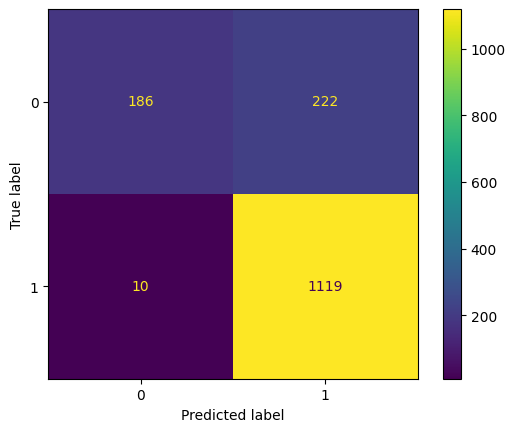

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

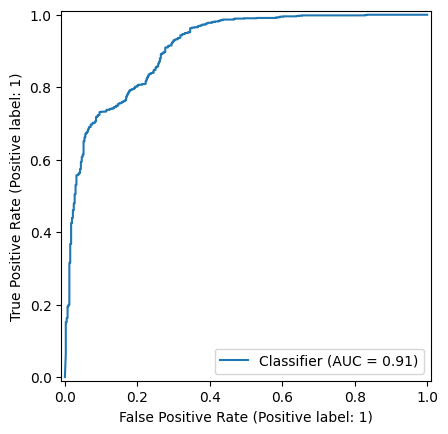

In [ ]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.show()

## 9. Inspect the fitted Gaussian Naive Bayes parameters

A nice feature of Naive Bayes for teaching is interpretability. For each class and each feature, the model estimates a mean and variance.

Inside the pipeline, the fitted `GaussianNB` object is stored under the step name `'clf'`.

In [ ]:
gnb = nb_model.named_steps['clf']

means = pd.DataFrame(gnb.theta_, columns=feature_cols, index=['class_0', 'class_1'])
variances = pd.DataFrame(gnb.var_, columns=feature_cols, index=['class_0', 'class_1'])

print('Class priors learned by the model:')
print(gnb.class_prior_)
print()
print('Class-conditional means:')
display(means)
print('Class-conditional variances:')
display(variances)

Class priors learned by the model:
[0.26550976 0.73449024]

Class-conditional means:


,pl_orbper,pl_orbsmax,pl_rade,pl_bmasse,pl_dens,pl_orbeccen,pl_eqt,pl_insol,st_teff,st_rad,st_mass,st_met,st_logg,sy_dist,sy_snum,sy_pnum
class_0,330365.683589,45.532082,9.843892,1142.771589,4.905874,0.163305,810.044706,101.055591,5420.777508,2.647669,0.933367,0.017966,4.211801,955.035757,1.165033,1.797386
class_1,23.989071,0.124148,4.371909,116.864178,4.316762,0.030168,922.726453,404.515299,5394.533314,1.010183,0.935815,0.017453,4.452248,609.160078,1.082103,1.773479


Class-conditional variances:


,pl_orbper,pl_orbsmax,pl_rade,pl_bmasse,pl_dens,pl_orbeccen,pl_eqt,pl_insol,st_teff,st_rad,st_mass,st_met,st_logg,sy_dist,sy_snum,sy_pnum
class_0,1.319203e+14,262398.900823,35079.730889,3.119020e+06,35809.602992,35047.460803,99405.900959,5.258765e+04,8.511555e+06,35089.207056,35047.820447,35047.460700,35047.898284,4.435286e+06,35047.601027,35048.778387
class_1,4.229640e+04,35047.449564,35068.410386,2.569770e+05,35581.246901,35047.429117,229983.866814,1.701016e+06,7.249643e+05,35047.610292,35047.490978,35047.449831,35047.480551,3.000300e+05,35047.515600,35048.787332


## 10. Predict on a few examples

This is useful for students because it shows how the classifier turns a feature vector into a probability.

In [ ]:
example_idx = X_test.sample(5, random_state=7).index
example_table = df.loc[example_idx, ['pl_name', 'discoverymethod'] + feature_cols].copy()
example_table['true_label'] = y.loc[example_idx].values
example_table['pred_label'] = nb_model.predict(X.loc[example_idx])
example_table['pred_prob_transit'] = nb_model.predict_proba(X.loc[example_idx])[:, 1]
example_table

,pl_name,discoverymethod,pl_orbper,pl_orbsmax,pl_rade,pl_bmasse,pl_dens,pl_orbeccen,pl_eqt,pl_insol,...,st_rad,st_mass,st_met,st_logg,sy_dist,sy_snum,sy_pnum,true_label,pred_label,pred_prob_transit
3037,Kepler-707 b,Transit,2.237493,0.0325,1.33,2.330000,5.440,0.0000,1160.0,336.673,...,0.760,0.800,-0.12,4.58,591.7760,1,1,1,1,9.999999e-01
5464,HD 33844 b,Radial Velocity,551.400020,1.6000,13.40,638.838300,1.460,0.1500,NaN,NaN,...,5.390,1.840,0.27,3.24,105.7790,1,2,0,1,9.999659e-01
4125,TOI-5573 b,Transit,8.797590,0.0712,9.75,112.000000,0.661,0.0720,528.0,12.920,...,0.594,0.619,0.42,4.68,186.5620,1,1,1,1,9.999978e-01
5451,Kepler-454 c,Radial Velocity,524.190000,1.2870,12.90,1433.406116,3.670,0.0053,NaN,NaN,...,1.066,1.030,0.32,4.40,230.8690,2,3,0,1,9.996755e-01
4140,HD 141937 b,Radial Velocity,653.219970,1.5000,11.90,8714.854920,28.400,0.4100,NaN,NaN,...,1.030,1.090,0.11,4.45,33.3622,1,1,0,0,3.666280e-55


## 11. Optional: switch to a more science-oriented target

A better astrobiology-flavored exercise is to define a target connected to a physical question. For example, you could classify whether a planet is a **simple habitable-zone candidate** using a coarse rule such as:

- `0.25 <= pl_insol <= 1.75`
- `pl_rade <= 1.8`

This is only a toy label, not a formal habitability definition. It is useful pedagogically.

To reduce label leakage, do **not** use `pl_insol` or `pl_rade` as predictors if you define the class directly from them. Instead, predict from host-star and orbital features.

In [ ]:
# Uncomment this block to try a simple HZ-style toy target.

# df_hz = df.copy()
# df_hz = df_hz.dropna(subset=['pl_insol', 'pl_rade'])
# df_hz['hz_toy'] = ((df_hz['pl_insol'].between(0.25, 1.75)) & (df_hz['pl_rade'] <= 1.8)).astype(int)
#
# hz_features = [
#     'pl_orbper',
#     'pl_orbsmax',
#     'st_teff',
#     'st_rad',
#     'st_mass',
#     'st_met',
#     'st_logg',
#     'sy_dist',
#     'sy_snum',
#     'sy_pnum',
# ]
#
# X2 = df_hz[hz_features]
# y2 = df_hz['hz_toy']
#
# X2_train, X2_test, y2_train, y2_test = train_test_split(
#     X2, y2, test_size=0.25, random_state=42, stratify=y2
# )
#
# hz_model = Pipeline([
#     ('imputer', SimpleImputer(strategy='median')),
#     ('clf', GaussianNB()),
# ])
#
# hz_model.fit(X2_train, y2_train)
# y2_pred = hz_model.predict(X2_test)
# y2_proba = hz_model.predict_proba(X2_test)[:, 1]
#
# print('HZ-toy accuracy:', accuracy_score(y2_test, y2_pred))
# print('HZ-toy ROC AUC :', roc_auc_score(y2_test, y2_proba))
# print(classification_report(y2_test, y2_pred, digits=4))

## 12. Scientific discussion points for class

### Why Gaussian Naive Bayes?
Because many exoplanet-archive features are continuous, and Gaussian Naive Bayes models each feature as a class-conditional normal distribution.

### What assumptions are being made?
1. Features are conditionally independent given the class.
2. Each feature is approximately Gaussian within each class.

Both assumptions are only approximations for real exoplanet data.

### Why can the method still work?
Because classification often depends more on getting the relative class scores roughly right than on perfectly modeling the full joint distribution.

### What are the limitations?
- correlated astrophysical features can be effectively double-counted,
- class probabilities can be miscalibrated,
- the choice of target may encode strong observational bias,
- missing-data handling matters a lot.

### Good student follow-up tasks
- compare GaussianNB with LogisticRegression,
- examine the most important differences in class-conditional means,
- log-transform strongly skewed features such as `pl_orbper`, `pl_insol`, `pl_bmasse`, and `sy_dist`,
- repeat the analysis with carefully chosen science labels.


## 13. Minimal comparison with Logistic Regression

Naive Bayes is **generative** in spirit, while Logistic Regression is **discriminative**. This quick comparison is often very useful in a master-level class.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

logreg_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000)),
])

logreg_model.fit(X_train, y_train)
y_pred_lr = logreg_model.predict(X_test)
y_proba_lr = logreg_model.predict_proba(X_test)[:, 1]

print('Logistic regression accuracy:', accuracy_score(y_test, y_pred_lr))
print('Logistic regression ROC AUC :', roc_auc_score(y_test, y_proba_lr))
print(classification_report(y_test, y_pred_lr, digits=4))

## 14. Save a cleaned analysis table

This is handy if students want to continue outside Colab.

In [ ]:
output_cols = ['pl_name', 'hostname', 'discoverymethod', 'is_transit'] + feature_cols
df[output_cols].to_csv('exoplanet_nb_working_table.csv', index=False)
print('Saved exoplanet_nb_working_table.csv')

## 15. Final remarks

This notebook is designed as a **clean teaching baseline**:

- real public astronomical data,
- a transparent probabilistic classifier,
- reproducible preprocessing,
- evaluation on a held-out test set,
- easy extension toward more physical astrobiology targets.

For a course, I would strongly recommend that students first run the default transit/non-transit demo, then redesign the label so the task is closer to a scientific question.